In [1]:
import pandas as pd
import os
from utils.ml_utils_v2 import EmissionsPredictionPipeline, MultiOutputEmissionsPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
SIMULATION_DIR_PATH = os.path.join(SSP_DIR_PATH, "sisepuede_summary_results_run_sisepuede_run_2025-08-10t10;29;30.545790")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")

In [4]:
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, "training_data_v4.2.csv")
training_df = pd.read_csv(TRAINING_DATA_PATH)
training_df = training_df.drop(columns=["primary_id", "future_id"])
training_df.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_frac_enfu_transmission_loss_fuel_electricity,group_6_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,group_7_nemomod_en,group_8_frac_fgtv_reduction_in_fugitive_leaks,group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_10_efficfactor_enfu_industrial_energy_fuel,...,group_52_gdp_mmm_usd,group_53_population_gnrl,group_54_elasticity_scoe_enerdem_per,group_55_elasticity_trde_mtkm_to_gdp_freight,group_56_elasticity_trde_pkm_to_gdppc,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use,emission_avg_last_five_years,emission_total,technical_cost
0,0.354682,0.681300,0.670551,0.371381,0.597378,0.390717,0.554668,0.176302,0.653196,0.648621,...,0.065254,0.452244,0.395609,0.190891,0.681412,0.199758,0.969220,198.512688,6648.349151,72.057617
1,0.023662,0.659807,0.066549,0.350365,0.536160,0.040042,0.101776,0.683933,0.343598,0.707471,...,0.017979,0.912414,0.894009,0.046745,0.000798,0.725034,0.902345,228.001674,7129.331813,-13.958464
2,0.414641,0.092022,0.227137,0.020454,0.832906,0.293800,0.601890,0.263913,0.878754,0.211035,...,0.416929,0.832413,0.406103,0.929365,0.575067,0.208350,0.175365,182.853198,6396.992675,35.944249
3,0.307337,0.204967,0.050181,0.805452,0.558369,0.506111,0.974177,0.923617,0.904693,0.923400,...,0.778987,0.995629,0.994153,0.946893,0.506764,0.227383,0.113647,132.272042,5771.905648,-5.660414
4,0.800355,0.458285,0.101171,0.738594,0.254548,0.034029,0.673997,0.851671,0.418375,0.308669,...,0.918567,0.183357,0.397512,0.328322,0.362234,0.947292,0.764492,173.059694,6393.870401,-14.126208


## EDA

In [5]:
edau = EDAUtils()

In [6]:
target_cols = [col for col in training_df.columns if "emission" in col] + ["technical_cost"]
target_cols

['emission_avg_last_five_years', 'emission_total', 'technical_cost']

In [7]:
lhs_group_cols = [col for col in training_df.columns if col.startswith("group_")]
lhs_group_cols

['group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha',
 'group_2_frac_agrc_agriculture_production_lost',
 'group_3_frac_agrc',
 'group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture',
 'group_5_frac_enfu_transmission_loss_fuel_electricity',
 'group_6_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis',
 'group_7_nemomod_en',
 'group_8_frac_fgtv_reduction_in_fugitive_leaks',
 'group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel',
 'group_10_efficfactor_enfu_industrial_energy_fuel',
 'group_11_scalar_inen_energy_demand',
 'group_12_frac_inen_energy',
 'group_13_frac_ippu_cement_clinker',
 'group_14_ef_ippu_tonne_c',
 'group_15_ef_ippu_tonne_n2o_per',
 'group_16_ef_ippu_tonne_c',
 'group_17_pij_lndu',
 'group_18_frac_lndu_improved_pastures',
 'group_19_lndu_reallocation_factor',
 'group_20_gasrf_lsmm_biogas_anaerobic',
 'group_21_frac_lvst_mm',
 'group_22_frac_lvst_mm',
 'group_23_frac_lvst_mm_chickens',
 'group_24_ef_lvst_entferm',
 'group_25_frac_gnrl_eating_red_meat

In [8]:
training_df[target_cols].describe()

,emission_avg_last_five_years,emission_total,technical_cost
count,990.000000,990.000000,990.000000
mean,196.815588,6689.449765,-28.268133
std,42.189580,626.720882,74.313857
min,100.337873,5218.478784,-297.888856
25%,164.591342,6209.301622,-78.260742
50%,194.328534,6649.792879,-25.401952
75%,228.314392,7163.891116,26.244830
max,315.859433,8459.085718,149.208209


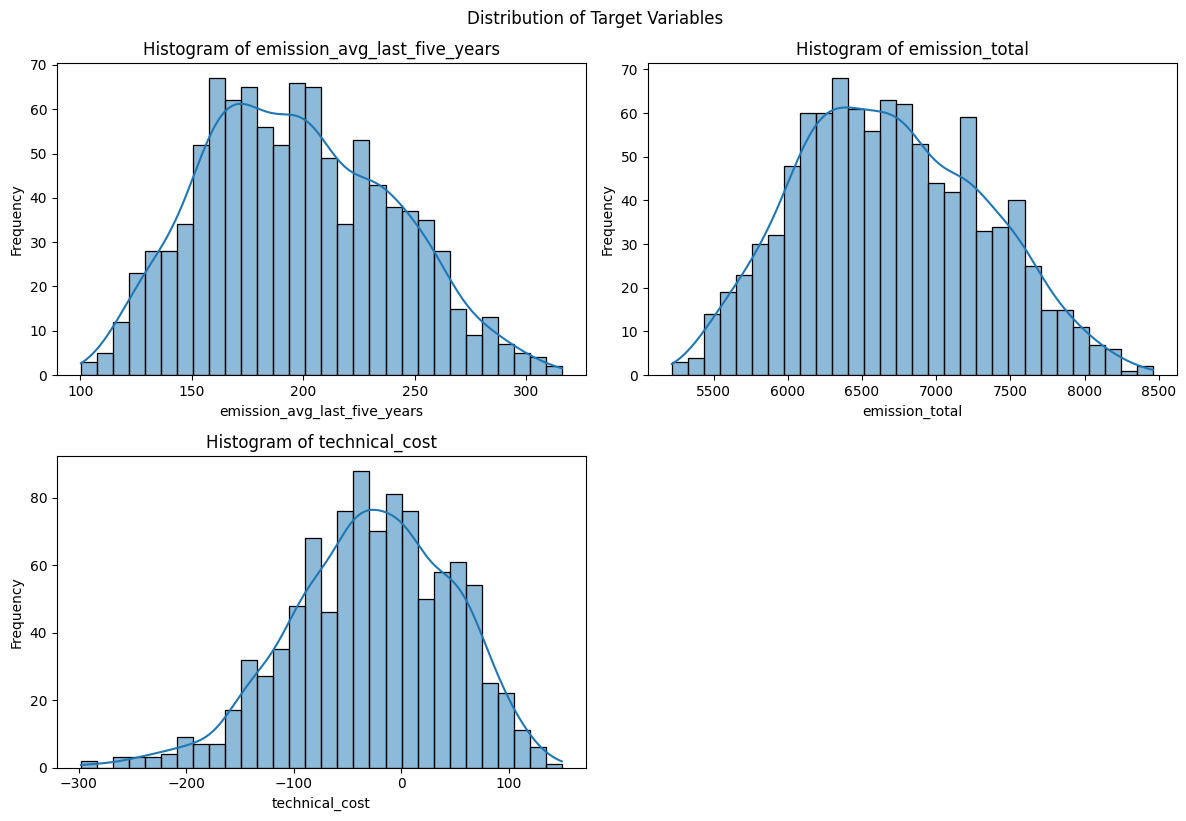

In [9]:
edau.plot_multiple_histograms(training_df, target_cols, title="Distribution of Target Variables")

In [10]:
edau.get_target_var_corr(training_df, "emission_total")
edau.get_target_var_corr(training_df, "emission_avg_last_five_years")
edau.get_target_var_corr(training_df, "technical_cost")


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
emission_total                 : 1.0000
emission_avg_last_five_years   : 0.9951
group_7_nemomod_en             : 0.7539
technical_cost                 : 0.7006
group_51_exports_enfu_pj_fuel  : 0.6109
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.2017
group_12_frac_inen_energy      : 0.1907
group_32_demscalar_trde        : 0.1207
group_36_frac_trns_fuelmix_road_light : 0.1189


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
emission_avg_last_five_years   : 1.0000
emission_total                 : 0.9951
group_7_nemomod_en             : 0.7832
technical_cost                 : 0.6629
group_51_exports_enfu_pj_fuel  : 0.5448
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.2259
group_12_frac_inen_energy      : 0.2008
group_36_frac_trns_fuelmix

In [11]:
# Find constant / near-constant cols
# const_cols = edau.find_constant_columns(training_df)
# near_const_cols = edau.find_near_constant_columns(training_df, threshold=1e-2)
# print("Constant:", const_cols)
# print("Near-constant:", near_const_cols)

In [12]:
# Outlier inspection
outliers = edau.find_outlier_columns(training_df, method="iqr", factor=1.5)
print("Outlier percentages:", outliers)

Outlier percentages: {'technical_cost': 0.81}


## Data Cleaning

In [13]:
dcu = DataCleaningUtils()

In [14]:
training_df.shape

(990, 61)

In [15]:
# # Check those -inf values in technical_cost
# technical_cost_neg_inf = training_df[training_df["technical_cost"] == -np.inf]
# technical_cost_neg_inf

In [16]:
# # filter out -inf values in technical_cost
# training_df = training_df[training_df["technical_cost"] != -np.inf]
# training_df.shape

In [17]:

training_df_cleaned = dcu.remove_outliers(training_df, method="iqr", factor=1.5)
print("Shape before removing outliers:", training_df.shape)
print("Shape after removing outliers:", training_df_cleaned.shape)

Shape before removing outliers: (990, 61)
Shape after removing outliers: (982, 61)


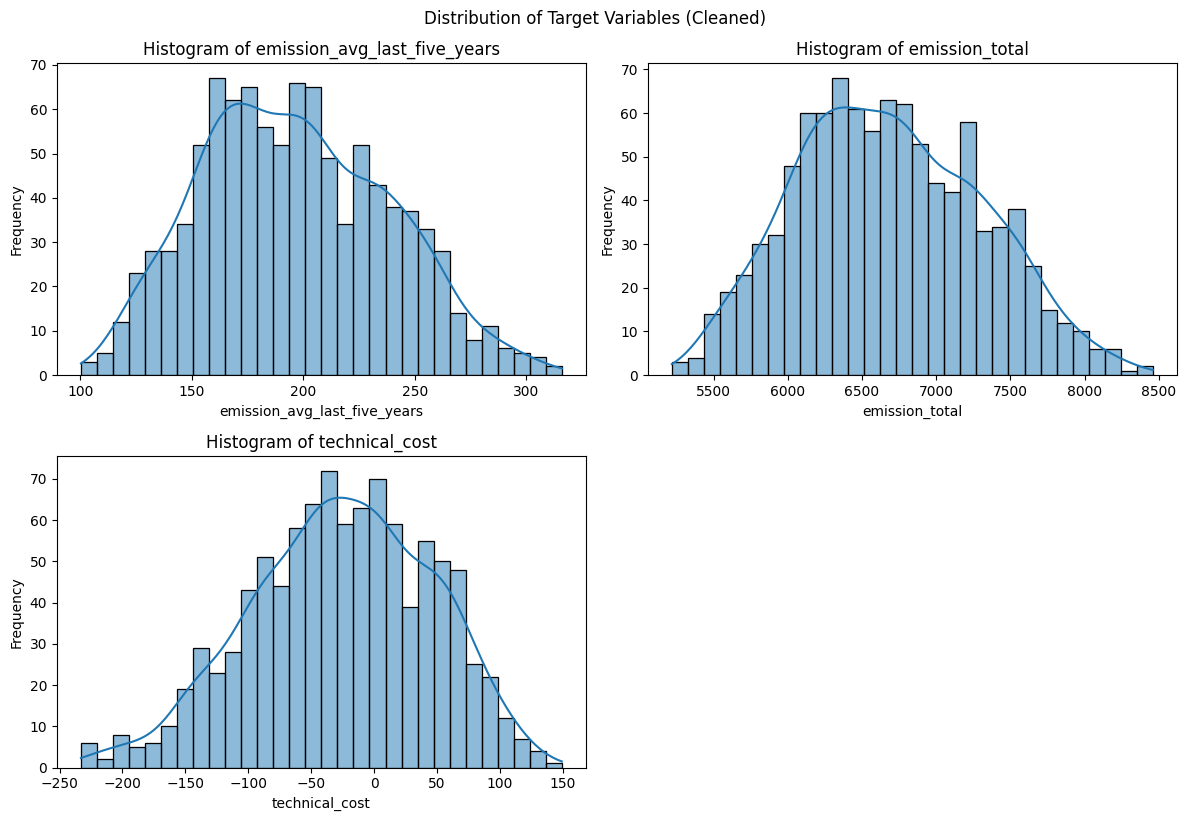

In [18]:
edau.plot_multiple_histograms(training_df_cleaned, target_cols, title="Distribution of Target Variables (Cleaned)")

In [19]:
outliers = edau.find_outlier_columns(training_df_cleaned, method="zscore", z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {}


In [20]:
edau.get_target_var_corr(training_df_cleaned, "emission_total")
edau.get_target_var_corr(training_df_cleaned, "emission_avg_last_five_years")
edau.get_target_var_corr(training_df_cleaned, "technical_cost")


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
emission_total                 : 1.0000
emission_avg_last_five_years   : 0.9950
group_7_nemomod_en             : 0.7489
technical_cost                 : 0.6943
group_51_exports_enfu_pj_fuel  : 0.6057
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.2053
group_12_frac_inen_energy      : 0.2053
group_36_frac_trns_fuelmix_road_light : 0.1279
group_32_demscalar_trde        : 0.1180


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
emission_avg_last_five_years   : 1.0000
emission_total                 : 0.9950
group_7_nemomod_en             : 0.7789
technical_cost                 : 0.6543
group_51_exports_enfu_pj_fuel  : 0.5385
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.2299
group_12_frac_inen_energy      : 0.2155
group_36_frac_trns_fuelmix

In [21]:
training_df_cleaned[target_cols].describe()

,emission_avg_last_five_years,emission_total,technical_cost
count,982.000000,982.000000,982.000000
mean,196.234731,6680.848311,-26.363607
std,41.826974,621.470742,71.517989
min,100.337873,5218.478784,-232.969403
25%,164.470155,6206.177153,-76.720002
50%,194.048427,6644.363510,-24.419463
75%,227.368670,7150.303323,26.854720
max,315.859433,8459.085718,149.208209


In [22]:
# sns.pairplot(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

In [23]:
# edau.plot_correlation_matrix(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

## ML

### Individual Training

In [24]:
# negative_emissions_df = training_df_cleaned[lhs_group_cols + ["total_negative_emissions"]]
# positive_emissions_df = training_df_cleaned[lhs_group_cols + ["total_positive_emissions"]]


In [25]:
# negative_epp = EmissionsPredictionPipeline(
#     df=negative_emissions_df,
#     target="total_negative_emissions",
#     test_size=0.2,
#     random_state=42,
# )

# negative_epp.run(tune=False, log_transform=False, create_plots=False)

In [26]:
# positive_epp = EmissionsPredictionPipeline(
#     df=positive_emissions_df,
#     target="total_positive_emissions",
#     test_size=0.2,
#     random_state=42,
# )
# positive_epp.run(tune=False, log_transform=False, create_plots=False)

### Multi Output Training

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGB hyperparameters: {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.5}

=== XGB ===
emission_total                
  Train → MAE: 14.0808, RMSE: 18.0722, R²: 0.9992, SMAPE: 0.2%
   Test → MAE: 76.2187, RMSE: 94.5349, R²: 0.9761, SMAPE: 1.1%
emission_avg_last_five_years  
  Train → MAE: 1.0567, RMSE: 1.3218, R²: 0.9990, SMAPE: 0.6%
   Test → MAE: 5.5287, RMSE: 7.0867, R²: 0.9701, SMAPE: 2.9%
technical_cost                
  Train → MAE: 2.4826, RMSE: 3.2168, R²: 0.9980, SMAPE: 12.6%
   Test → MAE: 12.6387, RMSE: 16.3610, R²: 0.9419, SMAPE: 42.3%

=== MeanBaseline ===
emission_total                
  Train → MAE: 514.1877, RMSE: 623.2248, R²: 0.0000, SMAPE: 7.7%
   Test → MAE: 499.8131, RMSE: 613.0305, R²: -0.0032, SMAPE: 7.5%
emission_avg_last_five_years  
  Train → MAE: 34.7210, RMSE: 41.9965, R²: 0.0000, SMAPE: 17.9%
   Test → MA

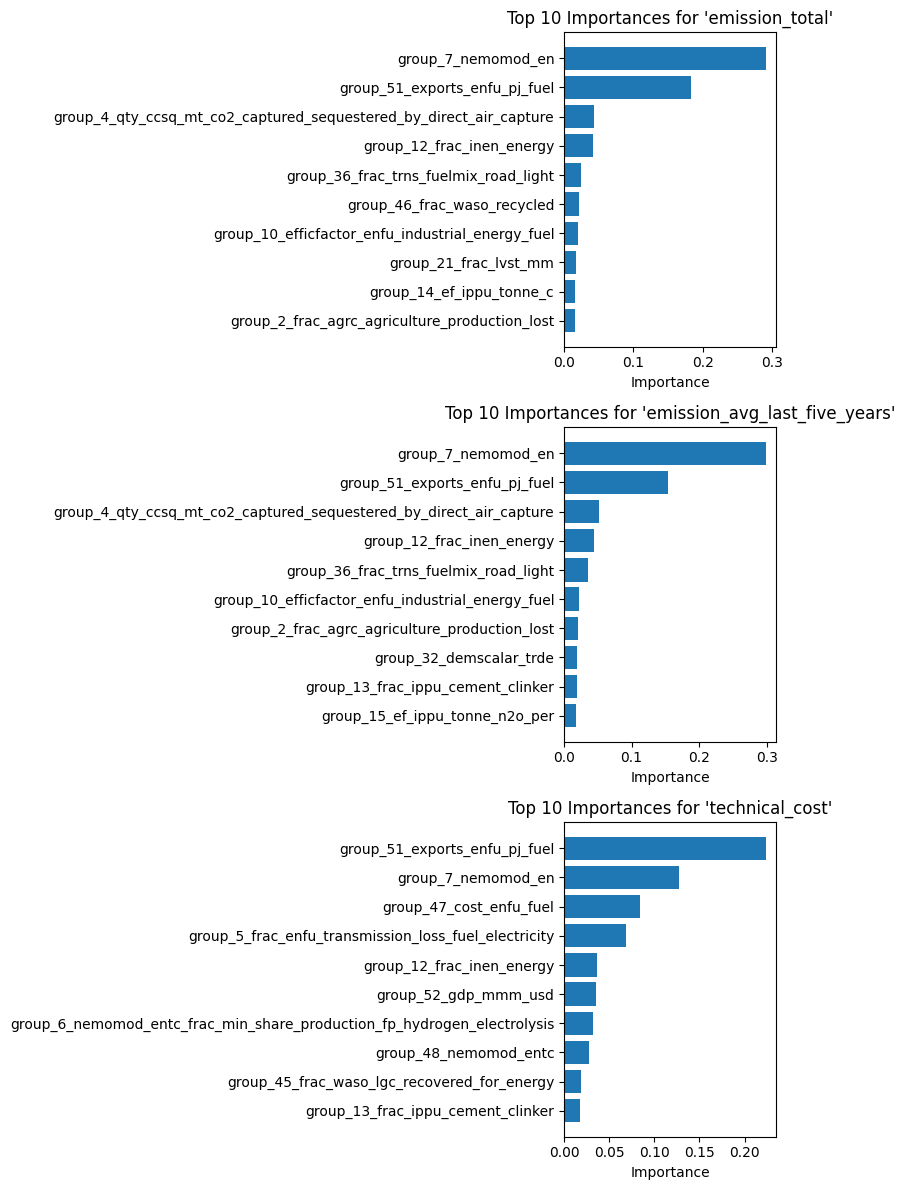

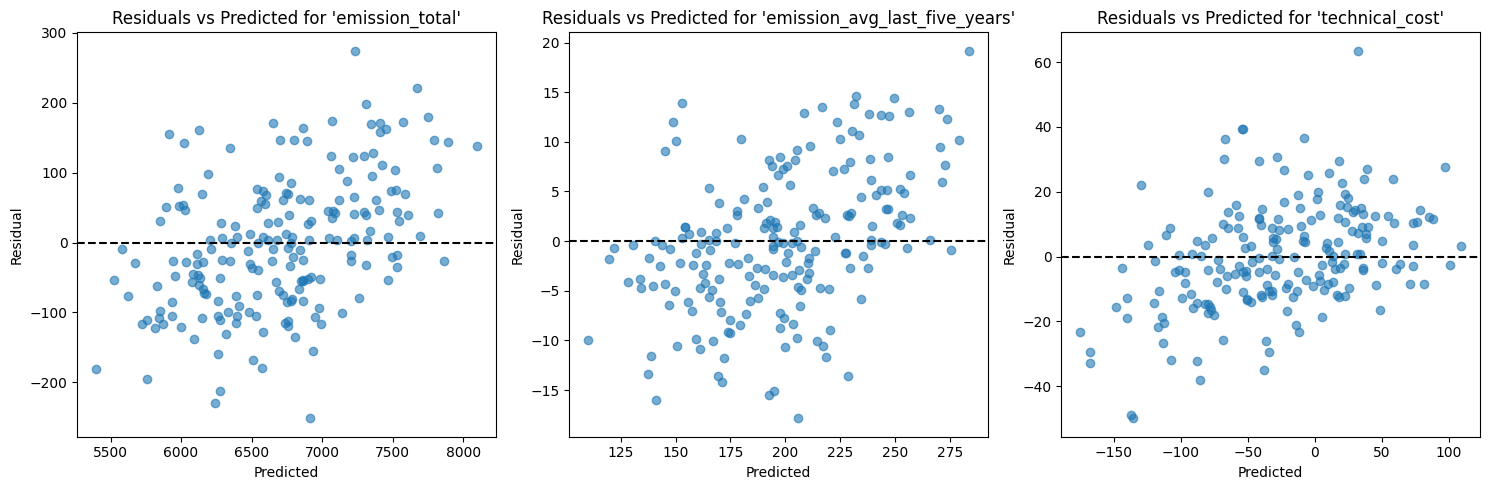

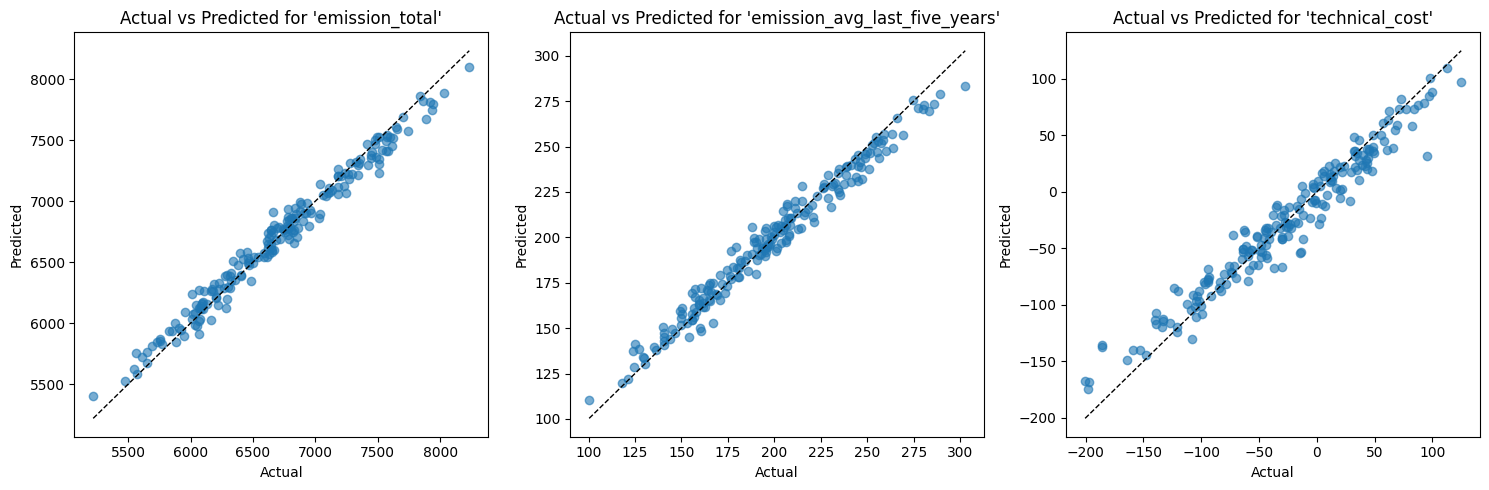

In [38]:
mulp = MultiOutputEmissionsPipeline(df=training_df_cleaned, targets=["emission_total", "emission_avg_last_five_years", "technical_cost"])
mulp.run(tune=True, log_transform=False, plot_figures=True)

## Save the trained and tuned model and use it to predict new data

In [39]:
training_df_cleaned.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_frac_enfu_transmission_loss_fuel_electricity,group_6_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,group_7_nemomod_en,group_8_frac_fgtv_reduction_in_fugitive_leaks,group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_10_efficfactor_enfu_industrial_energy_fuel,...,group_52_gdp_mmm_usd,group_53_population_gnrl,group_54_elasticity_scoe_enerdem_per,group_55_elasticity_trde_mtkm_to_gdp_freight,group_56_elasticity_trde_pkm_to_gdppc,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use,emission_avg_last_five_years,emission_total,technical_cost
0,0.354682,0.681300,0.670551,0.371381,0.597378,0.390717,0.554668,0.176302,0.653196,0.648621,...,0.065254,0.452244,0.395609,0.190891,0.681412,0.199758,0.969220,198.512688,6648.349151,72.057617
1,0.023662,0.659807,0.066549,0.350365,0.536160,0.040042,0.101776,0.683933,0.343598,0.707471,...,0.017979,0.912414,0.894009,0.046745,0.000798,0.725034,0.902345,228.001674,7129.331813,-13.958464
2,0.414641,0.092022,0.227137,0.020454,0.832906,0.293800,0.601890,0.263913,0.878754,0.211035,...,0.416929,0.832413,0.406103,0.929365,0.575067,0.208350,0.175365,182.853198,6396.992675,35.944249
3,0.307337,0.204967,0.050181,0.805452,0.558369,0.506111,0.974177,0.923617,0.904693,0.923400,...,0.778987,0.995629,0.994153,0.946893,0.506764,0.227383,0.113647,132.272042,5771.905648,-5.660414
4,0.800355,0.458285,0.101171,0.738594,0.254548,0.034029,0.673997,0.851671,0.418375,0.308669,...,0.918567,0.183357,0.397512,0.328322,0.362234,0.947292,0.764492,173.059694,6393.870401,-14.126208


In [40]:
# Get a single row from training_df_cleaned for prediction
single_row = training_df_cleaned.iloc[0].drop(["emission_total", "emission_avg_last_five_years", "technical_cost"])
single_row = single_row.to_frame().T  # Convert to DataFrame
single_row

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_frac_enfu_transmission_loss_fuel_electricity,group_6_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,group_7_nemomod_en,group_8_frac_fgtv_reduction_in_fugitive_leaks,group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_10_efficfactor_enfu_industrial_energy_fuel,...,group_49_nemomod_entc,group_50_nemomod_enst_capital_cost_st,group_51_exports_enfu_pj_fuel,group_52_gdp_mmm_usd,group_53_population_gnrl,group_54_elasticity_scoe_enerdem_per,group_55_elasticity_trde_mtkm_to_gdp_freight,group_56_elasticity_trde_pkm_to_gdppc,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use
0,0.354682,0.6813,0.670551,0.371381,0.597378,0.390717,0.554668,0.176302,0.653196,0.648621,...,0.115895,0.456909,0.389376,0.065254,0.452244,0.395609,0.190891,0.681412,0.199758,0.96922


In [41]:
# Predict using the trained model
predictions = mulp.predict(single_row)
print("Predictions for single row:")
print(predictions)
print("Original values:")
print(training_df_cleaned.iloc[0][["emission_total", "emission_avg_last_five_years", "technical_cost"]])

Predictions for single row:
   emission_total  emission_avg_last_five_years  technical_cost
0     6653.850586                    198.225571       66.502449
Original values:
emission_total                  6648.349151
emission_avg_last_five_years     198.512688
technical_cost                    72.057617
Name: 0, dtype: float64


In [42]:
# Save the trained model
xgb_pipeline = mulp.pipelines["XGB"]
TRAINED_MODELS_DIR = os.path.join(SCRIPT_DIR_PATH, "trained_models")
model_file_name = "xgb_pipeline_5.2.pkl"
os.makedirs(TRAINED_MODELS_DIR, exist_ok=True)
overwrite_existing_model = True  # Set to True to overwrite existing model

MODEL_PATH = os.path.join(TRAINED_MODELS_DIR, model_file_name)
if os.path.exists(MODEL_PATH) and not overwrite_existing_model:
    print(f"Model {model_file_name} already exists at {MODEL_PATH}. Make sure you don't overwrite an existing model.")
else:
    print(f"Saving model {model_file_name} to {MODEL_PATH}.")
    joblib.dump(xgb_pipeline, MODEL_PATH)


Saving model xgb_pipeline_5.2.pkl to /Users/tony/Documents/sisepuede_modeling/ssp_louisiana/metamodel/notebooks/trained_models/xgb_pipeline_5.2.pkl.


In [43]:
# Load the trained model and test predictions
xgb_pipeline_loaded = joblib.load(MODEL_PATH)

In [44]:
# Predict using the trained model
predictions = mulp.predict(single_row, ml_pipeline=xgb_pipeline_loaded)
print("Predictions for single row:")
print(predictions)

Predictions for single row:
   emission_total  emission_avg_last_five_years  technical_cost
0     6653.850586                    198.225571       66.502449
